**Estados de Bell**

Aqui vamos mostrar como é construido os estados de Bell através do Qiskit. Para isso, vamos considerar um sistema de dois qubits. Como explicado nos slides, o estado de Bell é alcançado com a utilização das portas quânticas Hadamard e CNOT. Mas antes, é necessário construir um circuito com 2 qubits e 2 bits clássicos registradores.

Primeiramente, instala as bibliotecas necessárias.

In [1]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

Fazendo os devidos importes

In [2]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import qiskit.quantum_info as qi
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

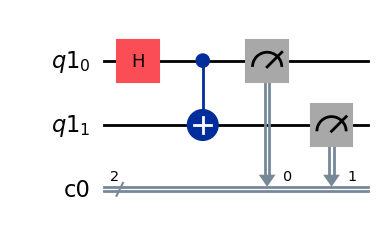

In [3]:
# Cria o circuito e faz as devidas operações. O circuito foi desenhado!
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.h(qr[0])
circuit.cx(qr[0], qr[1])
circuit.measure(qr, cr)
circuit.draw('mpl')

Para fazer os cálculos no computador quântico é necessário acessar o backend com o token da IBM.

In [4]:
service = QiskitRuntimeService(channel="ibm_quantum",
                               token = '39096e7a3b61144409089599e4a7c833fb42342fe2cfec9e66a416c322927860ac402202d87a09efdedb7eaafb98a5874bbf2def57ee0b6354c27878e2baa3da')
backend = service.least_busy(operational=True, simulator=False)

In [5]:
#Fazer a conta no computador quãntico da IBM. O cálculo fica numa fila para ser executado.
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(circuit)

Em seguida uma amostragem é realizada e o resultado é apresentado

Counts: {'10': 61, '00': 1967, '11': 2018, '01': 50}


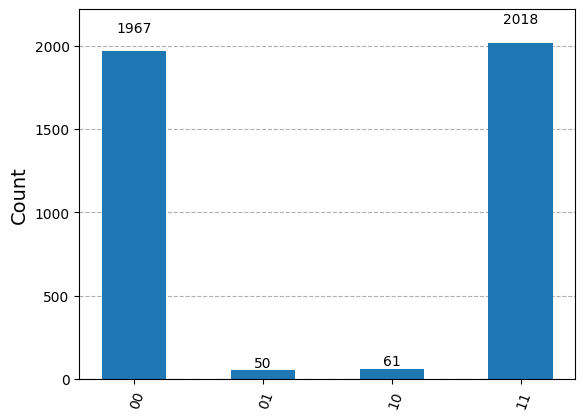

In [6]:
#Em seguida uma amostragem é realizada e o resultado é apresentado
sampler = Sampler(backend)
job = sampler.run([(isa_circuit)])
result = job.result()
pub_result = result[0]
counts = pub_result.data.c0.get_counts()
print("Counts:", counts)
plot_histogram(counts)

 Note que a figura mostra a documentação dos estados |01> e |10> com probabilidades pequenas. Mesmo que os estados de Bell sejam maximamente emaranhados, a detecção desses estados se deve ao fato de os computadores quânticos disponíveis serem suscetíveis a erros e ruídos no momento da execução do código. Existe um esforço no avanço da tecnologia de hardware quântico com intuito de diminuir esse erros a fim do resultado se tornar cada vez mais próximo à simulação. No entanto, é possível utilizar métodos de correção de erros para obtenção de resultados mais fiéis.